# Convolutional Neural Network (CNN)

> Implementación y entrenamiento de una **red neuronal convolucional** con **TensorFlow / Keras** sobre el dataset **Flores (tf_flowers)**: fotos reales a color de 5 especies de flor.

*Basado en las diapositivas `02a_Neural Networks.pdf` (pág. 12: "Redes Convolucionales Neuronales (CNNs): especialmente útiles para procesar imágenes; detectan características locales y las combinan en una representación global").*

## 1. Descripción

Una **Convolutional Neural Network (CNN)** es un tipo de red neuronal especializada en **procesar imágenes**. A diferencia de una FFNN/MLP —que aplana la imagen y pierde su estructura espacial— la CNN **conserva la forma 2D** y aprende a **detectar características locales** (bordes, texturas, formas) y combinarlas en una **representación global** (diapositiva pág. 12).

### Las 3 ideas clave de una CNN
1. **Convolución (`Conv2D`)**: pequeños **filtros** (p. ej. $3\times3$) se deslizan por la imagen detectando patrones locales. Cada filtro produce un **mapa de características** (*feature map*).
2. **Pooling (`MaxPooling2D`)**: reduce el tamaño quedándose con lo más relevante de cada región → menos cómputo e **invariancia a pequeñas traslaciones**.
3. **Jerarquía de características**: las primeras capas aprenden **bordes**; las profundas, **formas y objetos** completos.

### ¿Por qué es mejor que un MLP para imágenes?
- **Comparte pesos** (*parameter sharing*): el mismo filtro se usa en toda la imagen → **muchos menos parámetros** que un MLP equivalente.
- **Aprovecha la localidad**: píxeles vecinos están relacionados; la convolución lo explota.
- **Invariancia a la posición**: detecta una flor esté donde esté en la foto.

### Caso de uso de este notebook
Clasificar **fotografías reales** de flores (dataset *tf_flowers*) en 5 especies: **margarita, diente de león, rosa, girasol y tulipán**. A diferencia de MNIST/CIFAR (imágenes pequeñas pre-empaquetadas), aquí trabajamos con **fotos reales de tamaño variable** cargadas desde carpetas, lo que refleja un flujo de trabajo más realista.

## 2. Bibtex y Referencias

### BibTeX
```bibtex
@article{fukushima1980neocognitron,
  title   = {Neocognitron: A self-organizing neural network model for a mechanism of pattern recognition unaffected by shift in position},
  author  = {Fukushima, Kunihiko},
  journal = {Biological Cybernetics},
  volume  = {36}, number = {4}, pages = {193--202},
  year    = {1980}, publisher = {Springer}
}

@article{lecun1998gradient,
  title   = {Gradient-based learning applied to document recognition},
  author  = {LeCun, Yann and Bottou, L{\'e}on and Bengio, Yoshua and Haffner, Patrick},
  journal = {Proceedings of the IEEE},
  volume  = {86}, number = {11}, pages = {2278--2324},
  year    = {1998}, publisher = {IEEE}
}

@inproceedings{krizhevsky2012imagenet,
  title     = {ImageNet classification with deep convolutional neural networks},
  author    = {Krizhevsky, Alex and Sutskever, Ilya and Hinton, Geoffrey E.},
  booktitle = {Advances in Neural Information Processing Systems (NeurIPS)},
  volume    = {25}, pages = {1097--1105}, year = {2012}
}

@misc{tfflowers2019,
  title        = {Flowers dataset (tf\_flowers)},
  author       = {{The TensorFlow Team}},
  year         = {2019},
  howpublished = {\url{https://www.tensorflow.org/datasets/catalog/tf_flowers}}
}
```

### APA
- Fukushima, K. (1980). Neocognitron: A self-organizing neural network model for a mechanism of pattern recognition unaffected by shift in position. *Biological Cybernetics, 36*(4), 193–202.
- LeCun, Y., Bottou, L., Bengio, Y., & Haffner, P. (1998). Gradient-based learning applied to document recognition. *Proceedings of the IEEE, 86*(11), 2278–2324.
- Krizhevsky, A., Sutskever, I., & Hinton, G. E. (2012). ImageNet classification with deep convolutional neural networks. *Advances in Neural Information Processing Systems, 25*, 1097–1105.
- The TensorFlow Team. (2019). *Flowers dataset (tf_flowers)*. https://www.tensorflow.org/datasets/catalog/tf_flowers

## 3. Tipo de Modelo

| Criterio | Clasificación |
|---|---|
| **Método de aprendizaje** | Supervisado (cada foto tiene su etiqueta de especie) |
| **Por parámetros** | Paramétrico (filtros y pesos a ajustar, número fijo) |
| **Datos de aprendizaje** | Offline (*batch* / *mini-batch*) |
| **Resultado del entrenamiento** | **Red neuronal convolucional**: filtros + pesos por capa |

## 4. Algoritmo de Entrenamiento

Igual que en una FFNN: **Backpropagation + Gradiente Descendente** (optimizador **Adam**). Lo que se aprende son los **valores de los filtros** convolucionales y los pesos de las capas densas.

### Función de costo (clasificación multiclase)
$$J(W) = -\frac{1}{N}\sum_{n=1}^{N}\sum_{c=1}^{C} y_{n,c}\,\log(\hat{y}_{n,c})$$

### Regla de actualización
$$W \leftarrow W - \eta\,\frac{\partial J(W)}{\partial W}$$

El gradiente se calcula con **Backpropagation** (a través de convoluciones y pooling).

### Pseudocódigo
```text
Entrada:  D (imágenes etiquetadas), η (learning rate), E (épocas)
Inicializar filtros y pesos W aleatoriamente
para epoch = 1 .. E:
    para cada mini-batch (X, y) en D:
        ŷ = forward(X, W)        # data augmentation + convoluciones + pooling + densas
        L = costo(ŷ, y)
        grad = ∂L/∂W             # backpropagation
        W = W - η · grad         # Adam adapta η
devolver W
```

### Optimizador y regularización
- **Adam**: learning rate adaptativo (diapositivas págs. 33–34).
- **Data Augmentation**: giros/zoom aleatorios para generar más variedad y evitar memorizar.
- **Dropout** y **Early Stopping** para evitar *overfitting* (págs. 37–38).

## 5. Supuestos y Restricciones

- **Entrada con estructura espacial (rejilla)**: la CNN asume que la entrada es una imagen (alto × ancho × canales). **No se aplana** antes de las convoluciones.
- **Tamaño de entrada fijo**: las fotos reales tienen tamaños distintos → se **redimensionan** todas a $128\times128\times3$.
- **Entrada escalada**: los píxeles se normalizan a $[0,1]$ (con una capa `Rescaling`).
- **Localidad y estacionariedad**: los patrones útiles son locales y pueden aparecer en cualquier parte de la imagen.
- **Datos i.i.d.** y **suficientes ejemplos**; con datasets pequeños se usa *data augmentation*.
- **Costo computacional alto**: las convoluciones son costosas; idealmente **GPU** (en CPU es más lento).

## 6. Tests / Métricas de validación

| Métrica | Descripción |
|---|---|
| **Accuracy** | Proporción de fotos clasificadas correctamente. |
| **Loss (entropía cruzada)** | Función de costo monitorizada por época. |
| **Curvas de aprendizaje** | *Loss/Accuracy* de **train vs validación** → detectar over/underfitting. |
| **Matriz de confusión** | Aciertos y confusiones por clase (¿confunde rosa con tulipán?). |
| **Precision / Recall / F1** | Por clase y promediadas (`classification_report`). |
| **Comparación CNN vs MLP** | Demostrar que la convolución mejora sobre una red densa (sección 7.12). |

**Reglas / protocolo de validación** (cómo se prueba correctamente):
1. **Separar** los datos en **train / validación / test** (de forma estratificada).
2. El **test NUNCA** se usa durante el entrenamiento → mide la generalización real.
3. La **validación** se usa para *early stopping* y elegir hiperparámetros.
4. Comprobar el **gap train–validación**: si es grande → *overfitting*.

---

## 7. Implementación en TensorFlow / Keras

Flujo completo: descargar las fotos → explorar → preprocesar (redimensionar, **sin aplanar**) → separar train/val/test → construir la CNN (con *data augmentation*) → **entrenar (training iterations)** → graficar → evaluar → ver qué "ve" la CNN → comparar contra un MLP.

### 7.1 Imports y configuración

In [1]:
# Si se ejecuta en Colab o un entorno sin TensorFlow, descomentar:
# !pip install tensorflow scikit-learn matplotlib seaborn

import pathlib, gc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# Reproducibilidad
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = (128, 128)   # todas las fotos se redimensionan a este tamaño
BATCH    = 32

sns.set_theme(style="whitegrid")
print("TensorFlow:", tf.__version__)
print("GPU disponible:", bool(tf.config.list_physical_devices('GPU')))

TensorFlow: 2.17.0
GPU disponible: False


### 7.2 Descarga del dataset y análisis exploratorio

El dataset **tf_flowers** son ~3670 fotos reales repartidas en 5 carpetas (una por especie). Lo descargamos con `keras.utils.get_file` y lo cargamos con `image_dataset_from_directory`, que **lee las imágenes desde las carpetas y usa el nombre de cada carpeta como etiqueta**.

In [2]:
data_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = pathlib.Path(keras.utils.get_file("flower_photos", origin=data_url, untar=True))

# Cargamos TODAS las imágenes redimensionadas (shuffle=False: orden fijo para separar luego)
full_ds = keras.utils.image_dataset_from_directory(
    data_dir, image_size=IMG_SIZE, batch_size=BATCH,
    label_mode="int", shuffle=False,
)
CLASES_EN = full_ds.class_names           # ['daisy','dandelion','roses','sunflowers','tulips']
CLASES = ["margarita", "diente de león", "rosa", "girasol", "tulipán"]
print("Clases (carpetas):", CLASES_EN)
print("Etiquetas en español:", CLASES)

        0/228813984 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

    16384/228813984 ━━━━━━━━━━━━━━━━━━━━ 23:14 6us/step

    40960/228813984 ━━━━━━━━━━━━━━━━━━━━ 15:26 4us/step

    57344/228813984 ━━━━━━━━━━━━━━━━━━━━ 15:13 4us/step

    81920/228813984 ━━━━━━━━━━━━━━━━━━━━ 18:14 5us/step

...

228065280/228813984 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

228655104/228813984 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 23s 0us/step


Found 3670 files belonging to 5 classes.


Clases (carpetas): ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
Etiquetas en español: ['margarita', 'diente de león', 'rosa', 'girasol', 'tulipán']


Convertimos el dataset a arrays NumPy (lo mantenemos en `uint8` para ahorrar memoria; la normalización a [0,1] se hará dentro del modelo):

In [3]:
imgs, labs = [], []
for batch_x, batch_y in full_ds:
    imgs.append(batch_x.numpy().astype("uint8"))
    labs.append(batch_y.numpy())
X = np.concatenate(imgs); y = np.concatenate(labs)
del imgs, labs; gc.collect()

print("X:", X.shape, X.dtype, "| y:", y.shape)
print("Rango de píxeles:", X.min(), "-", X.max())

X: (3670, 128, 128, 3) uint8 | y: (3670,)
Rango de píxeles: 0 - 255


**Muestra de imágenes** — un ejemplo de cada clase:

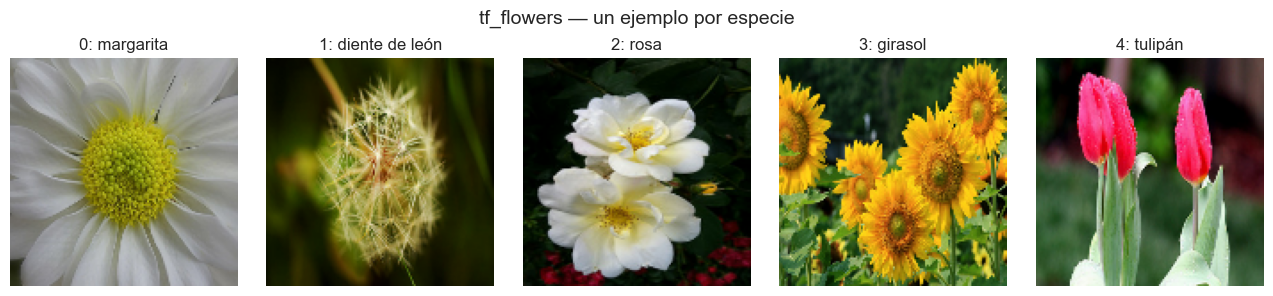

In [4]:
fig, axes = plt.subplots(1, 5, figsize=(13, 3))
for c, ax in enumerate(axes.ravel()):
    idx = np.argmax(y == c)
    ax.imshow(X[idx])
    ax.set_title(f"{c}: {CLASES[c]}")
    ax.axis("off")
fig.suptitle("tf_flowers — un ejemplo por especie", fontsize=14)
plt.tight_layout()
plt.show()

**Distribución de clases** — comprobamos cuántas fotos hay por especie:

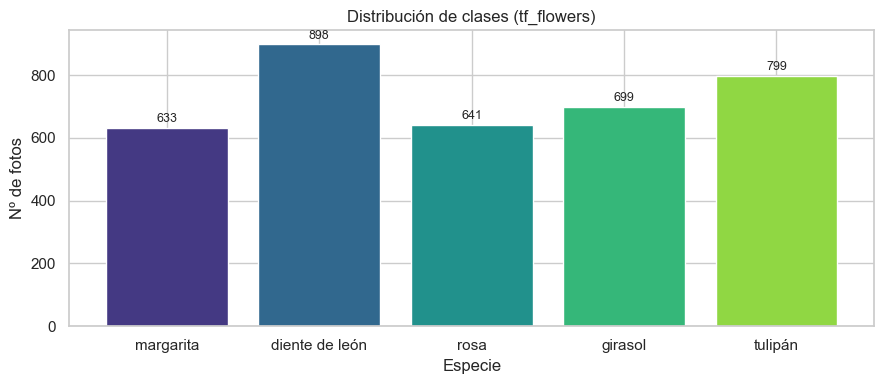

Total de imágenes: 3670


In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
classes, counts = np.unique(y, return_counts=True)
bars = ax.bar([CLASES[c] for c in classes], counts,
              color=sns.color_palette("viridis", 5))
ax.set_xlabel("Especie"); ax.set_ylabel("Nº de fotos")
ax.set_title("Distribución de clases (tf_flowers)")
ax.bar_label(bars, fmt="%d", padding=2, fontsize=9)
plt.tight_layout()
plt.show()
print("Total de imágenes:", len(y))

### 7.3 Preprocesamiento y separación train / validación / test

1. **Redimensionar** a $128\times128$ (ya hecho al cargar) → todas las fotos del mismo tamaño.
2. **NO aplanamos** — ¡diferencia clave con el MLP! Conservamos la forma $128\times128\times3$.
3. **Normalizar** a $[0,1]$ → se hará **dentro del modelo** con una capa `Rescaling`.
4. **Separar** en **train (70%) / validación (15%) / test (15%)** de forma **estratificada**.

In [6]:
# Primer split: 70% train, 30% temporal (estratificado)
x_train, x_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED)
# Segundo split: el 30% se reparte en validación (15%) y test (15%)
x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)

del X, y, x_temp, y_temp; gc.collect()

print(f"Entrenamiento: {x_train.shape[0]:>5} fotos -> {x_train.shape}")
print(f"Validación:    {x_val.shape[0]:>5} fotos -> {x_val.shape}")
print(f"Test:          {x_test.shape[0]:>5} fotos -> {x_test.shape}")

Entrenamiento:  2569 fotos -> (2569, 128, 128, 3)
Validación:      550 fotos -> (550, 128, 128, 3)
Test:            551 fotos -> (551, 128, 128, 3)


### 7.4 Construcción del modelo (CNN)

Incluimos en el propio modelo:
- **Data Augmentation** (giros y zoom aleatorios) → solo se aplica durante el entrenamiento.
- **Rescaling(1/255)** → normaliza los píxeles a $[0,1]$.
- Tres bloques **Conv2D + MaxPooling** + capas densas finales.

```
Entrada (128x128x3)
 → DataAugmentation (flip, rotación, zoom)   [solo en training]
 → Rescaling(1/255)
 → Conv2D(32) → MaxPool → Conv2D(64) → MaxPool → Conv2D(128) → MaxPool
 → Flatten → Dense(128, ReLU) → Dropout(0.5) → Dense(5, Softmax)
```

In [7]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="data_augmentation")

def build_cnn(dropout=0.5):
    return keras.Sequential([
        keras.Input(shape=(*IMG_SIZE, 3)),
        data_augmentation,
        layers.Rescaling(1.0 / 255),
        layers.Conv2D(32, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(5, activation="softmax"),
    ], name="CNN_Flores")

cnn = build_cnn(dropout=0.5)
cnn.summary()

Model: "CNN_Flores"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,288,325 (16.36 MB)

 Trainable params: 4,288,325 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

### 7.5 Compilación

- **Optimizador**: `Adam`.
- **Pérdida**: `sparse_categorical_crossentropy` (etiquetas enteras 0–4).
- **Métrica**: `accuracy`.

In [8]:
cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

### 7.6 Entrenamiento — *training iterations*

Entrenamos por **épocas** en mini-lotes (`batch_size=32`), con **Early Stopping** (diapositiva pág. 38). En CPU cada época tarda por el costo de las convoluciones.

In [9]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True, verbose=1,
)

history = cnn.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=25,
    batch_size=BATCH,
    callbacks=[early_stop],
    verbose=2,
)

print(f"\nÉpocas ejecutadas: {len(history.history['loss'])}")

Epoch 1/25


81/81 - 6s - 73ms/step - accuracy: 0.3807 - loss: 1.3845 - val_accuracy: 0.5236 - val_loss: 1.1906


Epoch 2/25


81/81 - 5s - 61ms/step - accuracy: 0.5029 - loss: 1.1766 - val_accuracy: 0.5582 - val_loss: 1.1181


Epoch 3/25


...

Epoch 18/25


81/81 - 5s - 62ms/step - accuracy: 0.7536 - loss: 0.6435 - val_accuracy: 0.7255 - val_loss: 0.8415


Epoch 18: early stopping


Restoring model weights from the end of the best epoch: 13.



Épocas ejecutadas: 18


### 7.7 Curvas de aprendizaje (loss y accuracy por época)

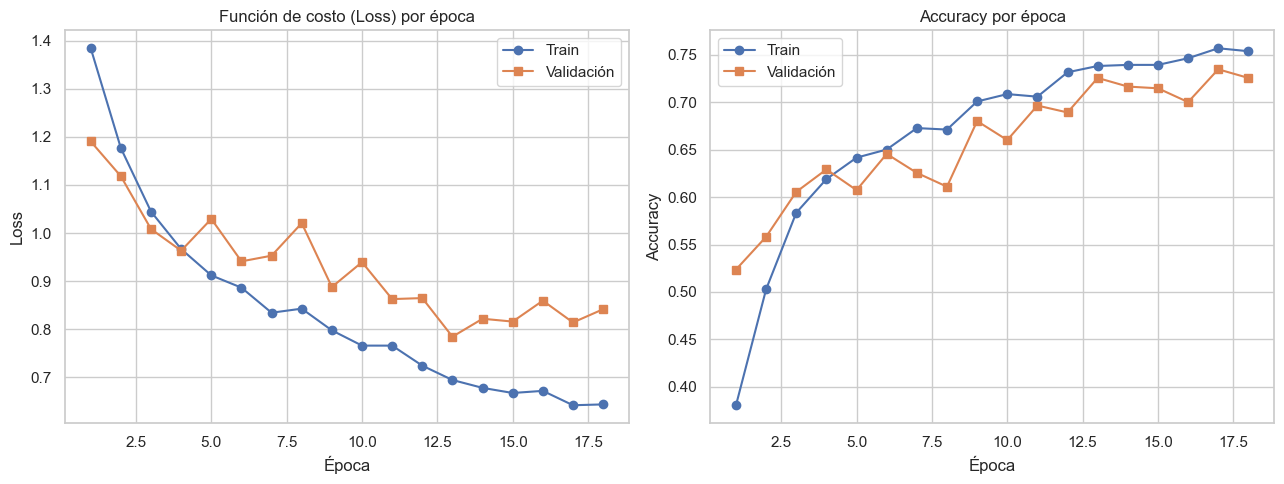

In [10]:
hist = history.history
epochs_range = range(1, len(hist["loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(epochs_range, hist["loss"], "o-", label="Train")
axes[0].plot(epochs_range, hist["val_loss"], "s-", label="Validación")
axes[0].set_title("Función de costo (Loss) por época")
axes[0].set_xlabel("Época"); axes[0].set_ylabel("Loss"); axes[0].legend()

axes[1].plot(epochs_range, hist["accuracy"], "o-", label="Train")
axes[1].plot(epochs_range, hist["val_accuracy"], "s-", label="Validación")
axes[1].set_title("Accuracy por época")
axes[1].set_xlabel("Época"); axes[1].set_ylabel("Accuracy"); axes[1].legend()
plt.tight_layout()
plt.show()

### 7.8 Evaluación final sobre el conjunto de test

In [11]:
test_loss, test_acc = cnn.evaluate(x_test, y_test, verbose=0)
print(f"Test  loss:     {test_loss:.4f}")
print(f"Test  accuracy: {test_acc:.4f}  ({test_acc*100:.2f} %)")

y_proba = cnn.predict(x_test, verbose=0)
y_pred = y_proba.argmax(axis=1)

print("\nClassification report:\n")
print(classification_report(y_test, y_pred, target_names=CLASES, digits=4))

Test  loss:     0.7372
Test  accuracy: 0.7223  (72.23 %)



Classification report:

                precision    recall  f1-score   support

     margarita     0.8056    0.6105    0.6946        95
diente de león     0.7361    0.7852    0.7599       135
          rosa     0.5872    0.6667    0.6244        96
       girasol     0.7717    0.9333    0.8448       105
       tulipán     0.7273    0.6000    0.6575       120

      accuracy                         0.7223       551
     macro avg     0.7255    0.7191    0.7162       551
  weighted avg     0.7270    0.7223    0.7189       551



### 7.9 Matriz de confusión

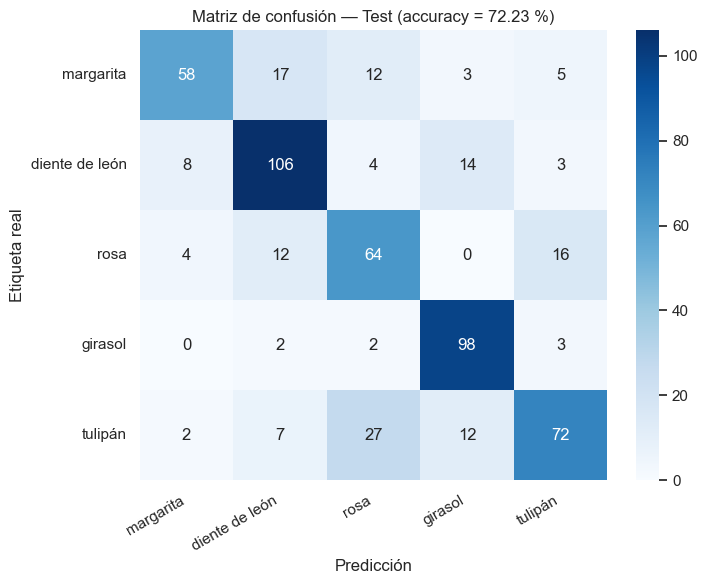

In [12]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True,
            xticklabels=CLASES, yticklabels=CLASES, ax=ax)
ax.set_xlabel("Predicción"); ax.set_ylabel("Etiqueta real")
ax.set_title(f"Matriz de confusión — Test (accuracy = {test_acc*100:.2f} %)")
plt.xticks(rotation=30, ha="right"); plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 7.10 Visualización de predicciones

Verde = acierto, rojo = error.

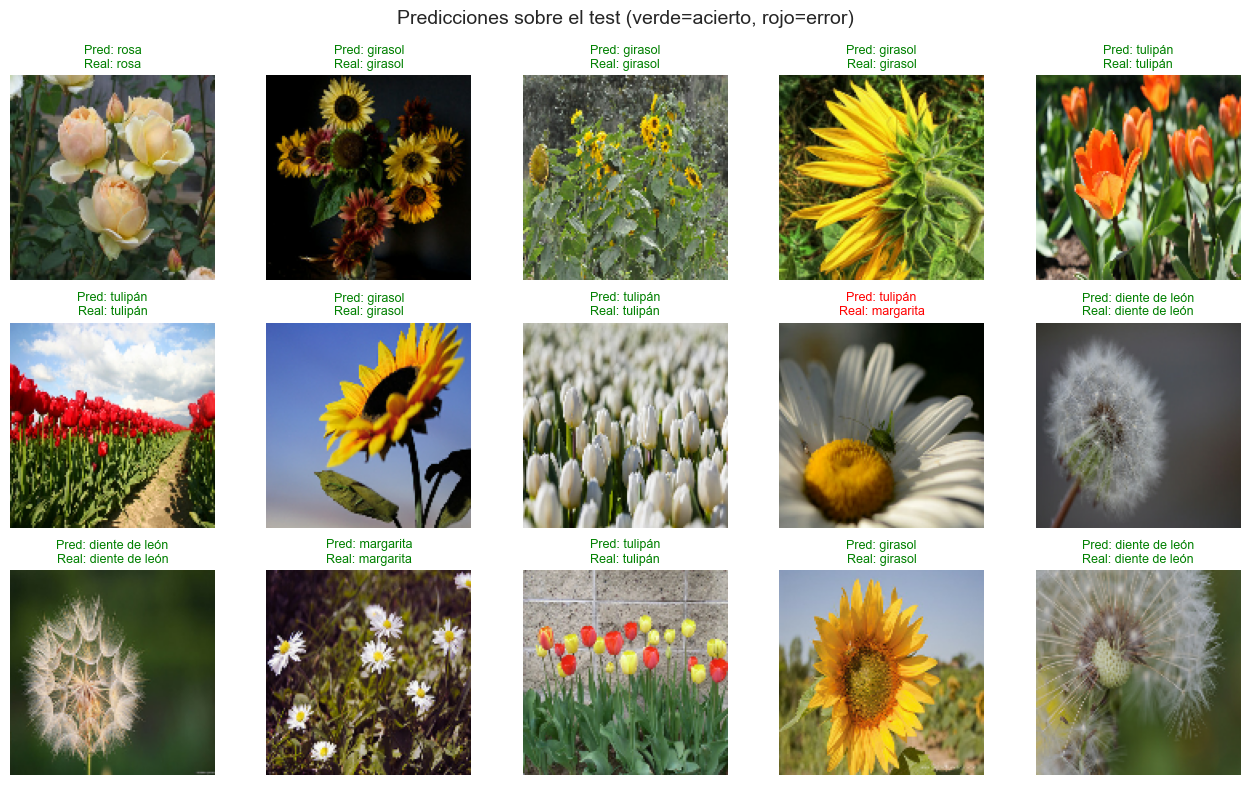

In [13]:
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(x_test), size=15, replace=False)

fig, axes = plt.subplots(3, 5, figsize=(13, 8))
for ax, i in zip(axes.ravel(), sample_idx):
    ax.imshow(x_test[i])
    ok = y_pred[i] == y_test[i]
    color = "green" if ok else "red"
    ax.set_title(f"Pred: {CLASES[y_pred[i]]}\nReal: {CLASES[y_test[i]]}",
                 color=color, fontsize=9)
    ax.axis("off")
fig.suptitle("Predicciones sobre el test (verde=acierto, rojo=error)", fontsize=14)
plt.tight_layout()
plt.show()

### 7.11 ¿Qué "ve" la CNN? — Mapas de características (*feature maps*)

Visualizamos la salida de la **primera capa convolucional** para una foto. Cada recuadro es lo que detecta un **filtro** distinto (bordes, colores, texturas): la *"detección de características locales"* de la diapositiva.

Imagen: rosa | feature maps shape: (128, 128, 32)


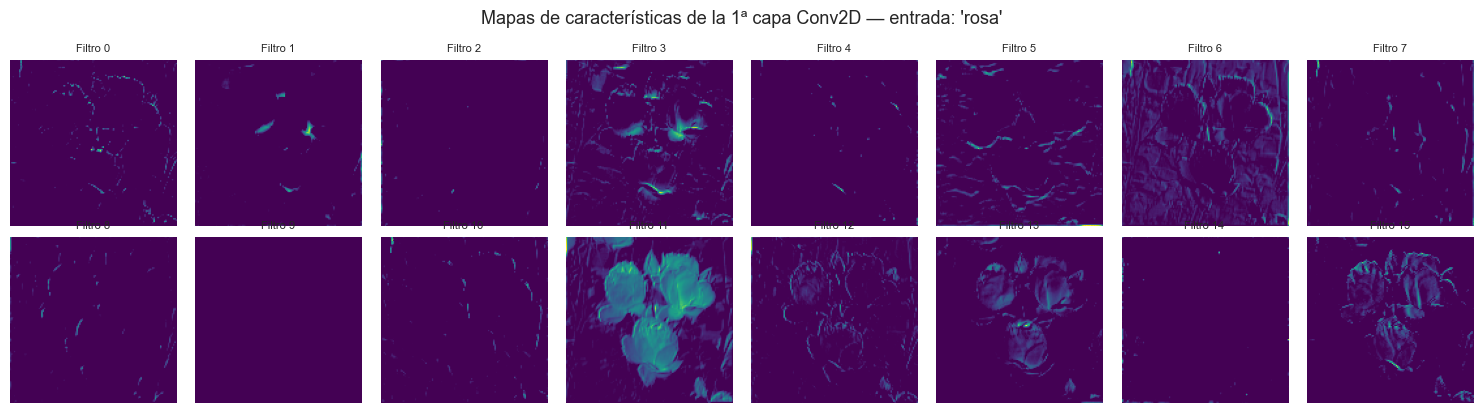

In [14]:
first_conv = next(l for l in cnn.layers if isinstance(l, layers.Conv2D))
activation_model = keras.Model(inputs=cnn.inputs, outputs=first_conv.output)

img_idx = sample_idx[0]
fmap = activation_model.predict(x_test[img_idx:img_idx + 1], verbose=0)[0]
print(f"Imagen: {CLASES[y_test[img_idx]]} | feature maps shape: {fmap.shape}")

fig, axes = plt.subplots(2, 8, figsize=(15, 4.2))
for k, ax in enumerate(axes.ravel()):
    ax.imshow(fmap[:, :, k], cmap="viridis")
    ax.set_title(f"Filtro {k}", fontsize=8)
    ax.axis("off")
fig.suptitle(f"Mapas de características de la 1ª capa Conv2D — entrada: '{CLASES[y_test[img_idx]]}'",
             fontsize=13)
plt.tight_layout()
plt.show()

### 7.12 Comparación: CNN vs MLP (¿por qué convolución?)

Entrenamos un **MLP** (red densa, como el notebook de FFNN) sobre las **mismas** fotos aplanadas, y comparamos. Se espera que la **CNN gane claramente**, demostrando el valor de la convolución para imágenes.

In [15]:
mlp = keras.Sequential([
    keras.Input(shape=(*IMG_SIZE, 3)),
    layers.Rescaling(1.0 / 255),
    layers.Flatten(),                      # aplanamos: se pierde la estructura 2D
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(5, activation="softmax"),
], name="MLP_baseline")

mlp.compile(optimizer=keras.optimizers.Adam(1e-3),
            loss="sparse_categorical_crossentropy", metrics=["accuracy"])
mlp.fit(x_train, y_train, validation_data=(x_val, y_val),
        epochs=20, batch_size=BATCH,
        callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=4,
                                                 restore_best_weights=True)],
        verbose=0)

mlp_loss, mlp_acc = mlp.evaluate(x_test, y_test, verbose=0)
print(f"MLP  -> Test accuracy: {mlp_acc*100:.2f} %  | parámetros: {mlp.count_params():,}")
print(f"CNN  -> Test accuracy: {test_acc*100:.2f} %  | parámetros: {cnn.count_params():,}")

MLP  -> Test accuracy: 24.50 %  | parámetros: 12,616,709
CNN  -> Test accuracy: 72.23 %  | parámetros: 4,288,325


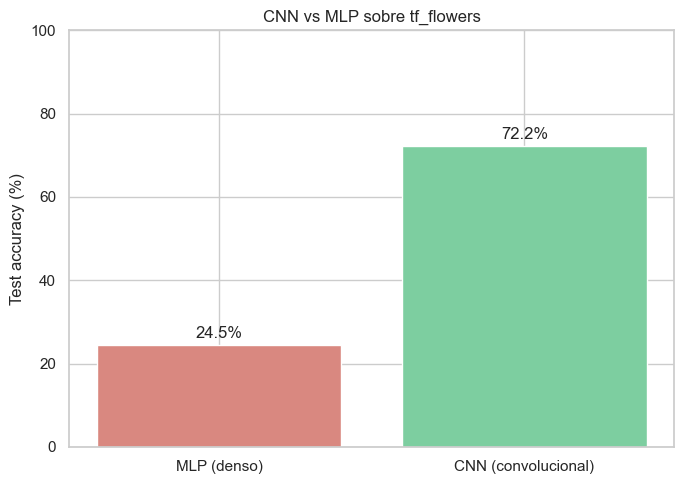

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))
modelos = ["MLP (denso)", "CNN (convolucional)"]
accs = [mlp_acc * 100, test_acc * 100]
bars = ax.bar(modelos, accs, color=["#d98880", "#7dcea0"])
ax.set_ylabel("Test accuracy (%)")
ax.set_title("CNN vs MLP sobre tf_flowers")
ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=12)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

## 8. Conclusión

- Implementamos una **CNN** con **TensorFlow / Keras** y la entrenamos sobre **fotos reales de flores** (tf_flowers).
- Aplicamos el flujo completo y **realista**: descarga desde carpetas, **redimensionado** a 128×128, normalización a $[0,1]$ **sin aplanar**, **separación train / validación / test** estratificada, **data augmentation**, construcción con bloques **Conv2D + MaxPooling**, **entrenamiento por épocas** (Backpropagation + Adam) y evaluación.
- La sección **7.11** muestra los **mapas de características** (cómo la red detecta bordes y texturas).
- La sección **7.12** demuestra que la **CNN supera al MLP** usando **menos parámetros** → la convolución es la herramienta correcta para imágenes.
- La **matriz de confusión** revela confusiones lógicas entre flores parecidas (p. ej. **rosa↔tulipán**, **margarita↔diente de león**).

### Posibles mejoras
- **Transfer learning** desde un modelo pre-entrenado en ImageNet (p. ej. MobileNetV2) → suele superar el 90%.
- **Batch Normalization** y arquitecturas más profundas.
- Más *data augmentation* y entrenar en **GPU** para más épocas.